In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
df = pd.read_csv(r"C:\Users\Lenovo\Downloads\Train.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 642175 entries, 0 to 642174
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   ID                             642175 non-null  object 
 1   timestamp                      642175 non-null  object 
 2   precipitation (mm)             642175 non-null  float64
 3   radiation (W/m2)               642175 non-null  int64  
 4   relativehumidity (-)           642175 non-null  float64
 5   temperature (degrees Celsius)  642175 non-null  float64
 6   station                        642175 non-null  object 
 7   station_name                   642175 non-null  object 
 8   country                        642175 non-null  object 
 9   installation_height            642175 non-null  float64
 10  elevation                      642175 non-null  float64
 11  latitude                       642175 non-null  float64
 12  longitude                     

In [56]:
df.duplicated().sum()

np.int64(0)

In [57]:
df["country"].unique()

array(['ML', 'KE', 'GH', 'MW', 'UG', 'NG', 'BJ'], dtype=object)

In [58]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [59]:
df['hour'] = df['timestamp'].dt.hour
df['minute'] = df['timestamp'].dt.minute
df['month'] = df['timestamp'].dt.month
df['day_of_year'] = df['timestamp'].dt.dayofyear

In [60]:
df['radiation (W/m2)'].describe()

count    642175.000000
mean        190.367792
std         281.677984
min           0.000000
25%           0.000000
50%           0.000000
75%         333.000000
max        1427.000000
Name: radiation (W/m2), dtype: float64

In [61]:
df['radiation (W/m2)'].value_counts().head()

radiation (W/m2)
0    322869
1      3540
2      2702
3      2064
5      1844
Name: count, dtype: int64

In [62]:
df.groupby('hour')['radiation (W/m2)'].agg(['count', 'mean', 'min', 'max'])

,count,mean,min,max
hour,,,,
0,26673,0.911034,0,200
1,26656,0.911014,0,200
2,26652,0.945370,0,222
3,26637,2.798363,0,216
4,26642,29.687111,0,403
5,26632,90.225593,0,727
6,26650,171.554559,0,916
7,26666,284.285082,0,1096
8,26703,411.010224,0,1329


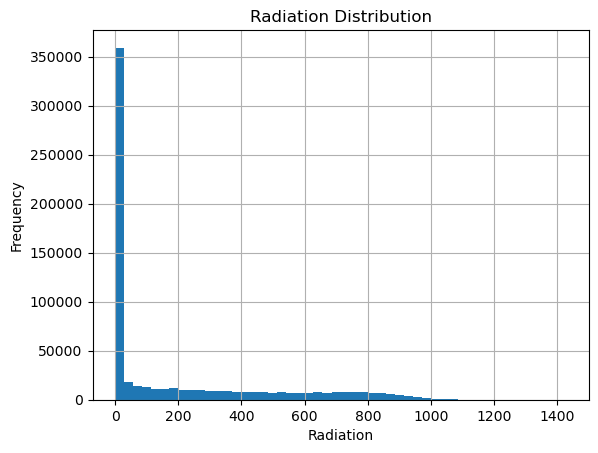

In [63]:
df['radiation (W/m2)'].hist(bins=50)
plt.xlabel('Radiation')
plt.ylabel('Frequency')
plt.title('Radiation Distribution')
plt.show()

In [64]:
df[['radiation (W/m2)',
    'temperature (degrees Celsius)',
    'relativehumidity (-)',
    'precipitation (mm)']].corr()

,radiation (W/m2),temperature (degrees Celsius),relativehumidity (-),precipitation (mm)
radiation (W/m2),1.000000,0.443269,-0.324471,-0.011027
temperature (degrees Celsius),0.443269,1.000000,-0.581012,0.001288
relativehumidity (-),-0.324471,-0.581012,1.000000,0.014276
precipitation (mm),-0.011027,0.001288,0.014276,1.000000


<Axes: >

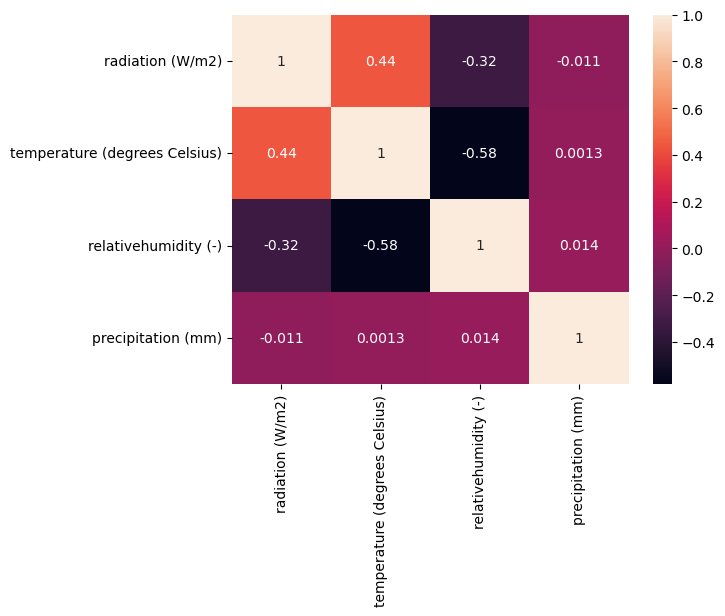

In [65]:
sns.heatmap(df[['radiation (W/m2)',
                    'temperature (degrees Celsius)',
                    'relativehumidity (-)',
                    'precipitation (mm)']].corr(), annot=True)

In [66]:
df['station'].unique()

array(['TA00349', 'TA00354', 'TA00344', 'TA00374', 'TA00121', 'TA00360',
       'TA00365', 'TA00335', 'TA00353', 'TA00078', 'TA00358', 'TA00122',
       'TA00359', 'TA00697', 'TA00117', 'TA00343', 'TA00134', 'TA00338',
       'TA00346', 'TA00328', 'TA00109', 'TA00325', 'TA00336', 'TA00331',
       'TA00330', 'TA00350', 'TA00337', 'TA00119', 'TA00587', 'TA00118',
       'TA00692', 'TA00333', 'TA00361', 'TA00342', 'TA00123', 'TA00348',
       'TA00355', 'TA00696', 'TA00334', 'TA00375'], dtype=object)

In [67]:
df['station'].value_counts()

station
TA00330    17437
TA00587    17416
TA00325    17344
TA00333    17109
TA00331    17094
TA00328    17013
TA00338    16939
TA00337    16833
TA00336    16739
TA00109    16712
TA00078    16658
TA00335    16643
TA00692    16620
TA00334    16559
TA00119    16460
TA00122    16257
TA00343    16237
TA00123    16223
TA00355    16171
TA00344    16155
TA00697    16084
TA00346    16076
TA00121    16004
TA00360    16000
TA00348    15995
TA00349    15807
TA00342    15791
TA00354    15648
TA00358    15614
TA00359    15517
TA00353    15492
TA00350    15407
TA00374    15400
TA00375    15313
TA00134    15208
TA00696    15196
TA00117    15194
TA00361    15102
TA00365    14995
TA00118    11713
Name: count, dtype: int64

In [68]:
df.groupby('station')['radiation (W/m2)'].agg(
    ['count', 'mean', 'min', 'max']
).sort_values('mean', ascending=False)

,count,mean,min,max
station,,,,
TA00355,16171,259.248902,0,1103
TA00348,15995,255.699469,0,1169
TA00359,15517,230.768576,0,1177
TA00354,15648,230.560455,0,1118
TA00346,16076,226.249565,0,1145
TA00344,16155,221.093717,0,1052
TA00334,16559,216.146386,0,1316
TA00375,15313,211.233396,0,1427
TA00365,14995,210.730577,0,1224


In [69]:
df[df['station'] == 'TA00338']['radiation (W/m2)'].describe()

count    16939.000000
mean        25.963457
std        117.629618
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       1221.000000
Name: radiation (W/m2), dtype: float64

In [70]:
df[df['station'] == 'TA00338'].groupby('timestamp')['radiation (W/m2)'].mean()

timestamp
2018-01-08 13:15:00    749.0
2018-01-08 13:30:00    549.0
2018-01-08 13:45:00    683.0
2018-01-08 14:00:00    706.0
2018-01-08 14:15:00    659.0
                       ...  
2018-11-30 22:45:00      0.0
2018-11-30 23:00:00      0.0
2018-11-30 23:15:00      0.0
2018-11-30 23:30:00      0.0
2018-11-30 23:45:00      0.0
Name: radiation (W/m2), Length: 16939, dtype: float64

In [71]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['timestamp'].diff().value_counts()

timestamp
0 days 00:15:00         641726
31 days 00:15:00            78
30 days 00:15:00            77
0 days 00:30:00             63
0 days 00:45:00             38
                         ...  
412 days 08:45:00            1
-1405 days +17:45:00         1
45 days 21:00:00             1
-674 days +13:30:00          1
-310 days +12:00:00          1
Name: count, Length: 76, dtype: int64

In [72]:
df = df.sort_values('timestamp').reset_index(drop=True)

In [73]:
gaps = df['timestamp'].diff()

In [74]:
gaps.value_counts().head(10)

timestamp
0 days 00:00:00     557251
0 days 00:15:00      84885
30 days 00:15:00        10
31 days 00:15:00        10
0 days 00:30:00          8
28 days 00:15:00         3
29 days 00:15:00         2
40 days 16:30:00         1
33 days 00:15:00         1
33 days 11:30:00         1
Name: count, dtype: int64

In [75]:
gaps[gaps != pd.Timedelta(minutes=15)].value_counts().head(20)

timestamp
0 days 00:00:00     557251
30 days 00:15:00        10
31 days 00:15:00        10
0 days 00:30:00          8
28 days 00:15:00         3
29 days 00:15:00         2
40 days 16:30:00         1
33 days 00:15:00         1
33 days 11:30:00         1
41 days 16:30:00         1
0 days 01:00:00          1
Name: count, dtype: int64

In [76]:
df.loc[
    gaps != pd.Timedelta(minutes=15),
    ['timestamp', 'station']
].head(20)

,timestamp,station
0,2016-01-11 10:30:00,TA00078
1974,2016-03-01 00:00:00,TA00078
4950,2016-05-01 00:00:00,TA00078
5460,2016-05-06 07:45:00,TA00078
7371,2016-05-26 05:45:00,TA00078
7890,2016-05-31 15:45:00,TA00078
7923,2016-07-01 00:00:00,TA00078
10899,2016-09-01 00:00:00,TA00078
13779,2016-11-01 00:00:00,TA00078
15337,2016-11-17 05:45:00,TA00078


In [77]:
df = df.sort_values(['station', 'timestamp'])
# hanrateb 3ala 7asab el station at first w gowa kol station hanrateb 7asab el timestamp
gaps = df.groupby('station')['timestamp'].diff()
#for each station calc the diff between each two consecutive timestamps
gaps.value_counts().head(20)

timestamp
0 days 00:15:00     641726
31 days 00:15:00        78
30 days 00:15:00        77
0 days 00:30:00         63
0 days 00:45:00         38
28 days 00:15:00        36
0 days 01:15:00         30
0 days 01:00:00         24
0 days 01:30:00         16
0 days 01:45:00          6
0 days 06:15:00          4
0 days 05:15:00          3
0 days 02:00:00          3
0 days 05:00:00          3
0 days 02:30:00          3
29 days 00:15:00         3
0 days 02:45:00          2
0 days 03:45:00          1
0 days 05:30:00          1
31 days 13:30:00         1
Name: count, dtype: int64

In [78]:
gaps[gaps > pd.Timedelta(minutes=15)].value_counts().head(20)

timestamp
31 days 00:15:00    78
30 days 00:15:00    77
0 days 00:30:00     63
0 days 00:45:00     38
28 days 00:15:00    36
0 days 01:15:00     30
0 days 01:00:00     24
0 days 01:30:00     16
0 days 01:45:00      6
0 days 06:15:00      4
0 days 02:00:00      3
0 days 05:00:00      3
0 days 05:15:00      3
29 days 00:15:00     3
0 days 02:30:00      3
0 days 02:45:00      2
0 days 23:00:00      1
31 days 02:00:00     1
0 days 05:30:00      1
31 days 13:30:00     1
Name: count, dtype: int64

In [79]:
#add the gap as a column in the dataframe
df['gap'] = df.groupby('station')['timestamp'].diff()
#rows --> of the gap >15, from these rows get ['station', 'timestamp', 'gap'] only
df[df['gap'] > pd.Timedelta(minutes=15)][
    ['station', 'timestamp', 'gap']
].head(30)

,station,timestamp,gap
1974,TA00078,2016-03-01 00:00:00,29 days 00:15:00
4950,TA00078,2016-05-01 00:00:00,30 days 00:15:00
5460,TA00078,2016-05-06 07:45:00,0 days 00:30:00
7371,TA00078,2016-05-26 05:45:00,0 days 00:30:00
7890,TA00078,2016-05-31 15:45:00,0 days 00:30:00
7923,TA00078,2016-07-01 00:00:00,30 days 00:15:00
10899,TA00078,2016-09-01 00:00:00,31 days 00:15:00
13779,TA00078,2016-11-01 00:00:00,31 days 00:15:00
15337,TA00078,2016-11-17 05:45:00,0 days 00:30:00
26328,TA00109,2017-03-01 00:00:00,28 days 00:15:00


In [80]:
df['gap'] = df.groupby('station')['timestamp'].diff()

missing_intervals = df[
    (df['gap'] > pd.Timedelta(minutes=15)) &
    (df['timestamp'].dt.month % 2 == 1)
]

missing_intervals[['station', 'timestamp', 'gap']].head(20)

,station,timestamp,gap
1974,TA00078,2016-03-01 00:00:00,29 days 00:15:00
4950,TA00078,2016-05-01 00:00:00,30 days 00:15:00
5460,TA00078,2016-05-06 07:45:00,0 days 00:30:00
7371,TA00078,2016-05-26 05:45:00,0 days 00:30:00
7890,TA00078,2016-05-31 15:45:00,0 days 00:30:00
7923,TA00078,2016-07-01 00:00:00,30 days 00:15:00
10899,TA00078,2016-09-01 00:00:00,31 days 00:15:00
13779,TA00078,2016-11-01 00:00:00,31 days 00:15:00
15337,TA00078,2016-11-17 05:45:00,0 days 00:30:00
26328,TA00109,2017-03-01 00:00:00,28 days 00:15:00


In [81]:
missing_intervals.shape

(409, 18)

In [82]:
df[df['gap'] > pd.Timedelta(minutes=15)][
    ['station', 'timestamp', 'gap']
].head(30)

,station,timestamp,gap
1974,TA00078,2016-03-01 00:00:00,29 days 00:15:00
4950,TA00078,2016-05-01 00:00:00,30 days 00:15:00
5460,TA00078,2016-05-06 07:45:00,0 days 00:30:00
7371,TA00078,2016-05-26 05:45:00,0 days 00:30:00
7890,TA00078,2016-05-31 15:45:00,0 days 00:30:00
7923,TA00078,2016-07-01 00:00:00,30 days 00:15:00
10899,TA00078,2016-09-01 00:00:00,31 days 00:15:00
13779,TA00078,2016-11-01 00:00:00,31 days 00:15:00
15337,TA00078,2016-11-17 05:45:00,0 days 00:30:00
26328,TA00109,2017-03-01 00:00:00,28 days 00:15:00


In [83]:
df[df['gap'] > pd.Timedelta(minutes=15)]['gap'].value_counts().head(20)

gap
31 days 00:15:00    78
30 days 00:15:00    77
0 days 00:30:00     63
0 days 00:45:00     38
28 days 00:15:00    36
0 days 01:15:00     30
0 days 01:00:00     24
0 days 01:30:00     16
0 days 01:45:00      6
0 days 06:15:00      4
0 days 02:00:00      3
0 days 05:00:00      3
0 days 05:15:00      3
29 days 00:15:00     3
0 days 02:30:00      3
0 days 02:45:00      2
0 days 23:00:00      1
31 days 02:00:00     1
0 days 05:30:00      1
31 days 13:30:00     1
Name: count, dtype: int64

In [84]:
df.groupby(df['timestamp'].dt.month)['radiation (W/m2)'].count()
#the amount of radiation for each odd month

timestamp
1      58877
3     116045
5     119036
7     118297
9     114839
11    115081
Name: radiation (W/m2), dtype: int64

In [85]:
df.isnull().sum()

ID                                0
timestamp                         0
precipitation (mm)                0
radiation (W/m2)                  0
relativehumidity (-)              0
temperature (degrees Celsius)     0
station                           0
station_name                      0
country                           0
installation_height               0
elevation                         0
latitude                          0
longitude                         0
hour                              0
minute                            0
month                             0
day_of_year                       0
gap                              40
dtype: int64

In [86]:
df = df.sort_values(['station', 'timestamp'])
df['gap'] = df.groupby('station')['timestamp'].diff()
real_gaps = df[(df['gap'] > pd.Timedelta(minutes=15)) & (df['timestamp'].dt.month % 2 == 1)]
print(real_gaps['station'].value_counts())

station
TA00331    83
TA00121    71
TA00692    17
TA00697    15
TA00109    15
TA00365    13
TA00336    11
TA00078     9
TA00119     7
TA00123     7
TA00359     7
TA00587     7
TA00134     6
TA00355     6
TA00358     6
TA00360     6
TA00350     6
TA00122     6
TA00330     6
TA00328     6
TA00354     5
TA00374     5
TA00361     5
TA00117     5
TA00696     5
TA00375     5
TA00349     5
TA00353     5
TA00325     5
TA00348     5
TA00346     5
TA00344     5
TA00342     5
TA00338     5
TA00337     5
TA00335     5
TA00334     5
TA00333     5
TA00343     5
TA00118     4
Name: count, dtype: int64


In [87]:
df = df.sort_values(['station', 'timestamp'])
df['gap'] = df.groupby('station')['timestamp'].diff()
real_gaps = df[(df['gap'] > pd.Timedelta(minutes=15)) & (df['timestamp'].dt.month % 2 == 1)]
print(real_gaps['station'].value_counts())
#sorts the data by station and time,then calculates the time difference between each reading and the one before it/ per station

station
TA00331    83
TA00121    71
TA00692    17
TA00697    15
TA00109    15
TA00365    13
TA00336    11
TA00078     9
TA00119     7
TA00123     7
TA00359     7
TA00587     7
TA00134     6
TA00355     6
TA00358     6
TA00360     6
TA00350     6
TA00122     6
TA00330     6
TA00328     6
TA00354     5
TA00374     5
TA00361     5
TA00117     5
TA00696     5
TA00375     5
TA00349     5
TA00353     5
TA00325     5
TA00348     5
TA00346     5
TA00344     5
TA00342     5
TA00338     5
TA00337     5
TA00335     5
TA00334     5
TA00333     5
TA00343     5
TA00118     4
Name: count, dtype: int64


In [88]:
df.isna().sum()
#Check for missing values in columns
# fi step 3 kona bendawar 3ala rows na2sa belkamel 3an tariq el timestamp  
#laken hena bendawar 3ala missing values in the row itself (mawgood 3adi bas fi missing values)

ID                                0
timestamp                         0
precipitation (mm)                0
radiation (W/m2)                  0
relativehumidity (-)              0
temperature (degrees Celsius)     0
station                           0
station_name                      0
country                           0
installation_height               0
elevation                         0
latitude                          0
longitude                         0
hour                              0
minute                            0
month                             0
day_of_year                       0
gap                              40
dtype: int64

In [89]:
#main idea :fill short gaps
df = df.set_index('timestamp')

df['radiation (W/m2)'] = df.groupby('station')['radiation (W/m2)'] \
    .transform(lambda x: x.interpolate(method='time', limit=4))

df = df.reset_index() # benraga3 tani el timestamp as a column badal ma howa index 



In [90]:
df['radiation_was_missing'] = df['radiation (W/m2)'].isna()

In [91]:
df.columns

Index(['timestamp', 'ID', 'precipitation (mm)', 'radiation (W/m2)',
       'relativehumidity (-)', 'temperature (degrees Celsius)', 'station',
       'station_name', 'country', 'installation_height', 'elevation',
       'latitude', 'longitude', 'hour', 'minute', 'month', 'day_of_year',
       'gap', 'radiation_was_missing'],
      dtype='object')

In [92]:
import requests

def get_nasa_power(lat, lon, start, end):
    url = "https://power.larc.nasa.gov/api/temporal/hourly/point"
    params = {
        "parameters": "ALLSKY_SFC_SW_DWN,T2M,RH2M,PRECTOTCORR",
        #solar radiation, temperature, relative humidity, Precipitation
        "community": "RE",
        #Renewable Energy community's settings
        "longitude": lon,
        "latitude": lat,
        "start": start,
        "end": end,
        "format": "JSON"
        #return data in JSON format
    }
    r = requests.get(url, params=params)
    return r.json()
    # convert the response  NASA --> Python Dictionary

In [93]:
stations_df = df[['station', 'latitude', 'longitude']].drop_duplicates()
stations_df
#remove the duplicates 

,station,latitude,longitude
0,TA00078,-0.200178,36.376936
16658,TA00109,5.592651,-0.996417
33370,TA00117,5.895083,0.989567
48564,TA00118,5.641413,-0.011870
60277,TA00119,5.161209,-2.641401
76737,TA00121,5.053207,-2.877294
92741,TA00122,5.778639,-2.090195
108998,TA00123,5.963177,-1.792334
125221,TA00134,-1.274462,36.809757
140429,TA00325,-15.488575,34.970907


In [94]:
df['timestamp'].min(), df['timestamp'].max()
#ben3raf el data bada2et men emta la7ad emta

(Timestamp('2016-01-11 10:30:00'), Timestamp('2020-11-30 23:45:00'))

In [95]:
import json, os
os.makedirs("EO_data", exist_ok =True)
#ben3mel folder --> EO_data w lw mawgood khalas true
print(stations_df)
for station, latitude, longitude in stations_df.values:
    print(f"Downloading data for {station}...")
    data = get_nasa_power(latitude, longitude, "20170101", "20191231")
    #hatli data el station di  for example men awel 01-01-2017 to 31-12-2019
    filepath = f"EO_data/{station}.json"
    with open (filepath, "w") as f:
        #open a file for each station
        json.dump(data, f)
        print(f"Saved: {filepath}")

        station   latitude  longitude
0       TA00078  -0.200178  36.376936
16658   TA00109   5.592651  -0.996417
33370   TA00117   5.895083   0.989567
48564   TA00118   5.641413  -0.011870
60277   TA00119   5.161209  -2.641401
76737   TA00121   5.053207  -2.877294
92741   TA00122   5.778639  -2.090195
108998  TA00123   5.963177  -1.792334
125221  TA00134  -1.274462  36.809757
140429  TA00325 -15.488575  34.970907
157773  TA00328  10.822359  -7.739400
174786  TA00330 -15.756620  35.254139
192223  TA00331 -15.763918  35.043804
209317  TA00333  11.891441  -7.337038
226426  TA00334  12.415836  -5.441847
242985  TA00335  11.852760  -6.018243
259628  TA00336  11.324207  -5.676385
276367  TA00337  10.461182  -7.449116
293200  TA00338  10.788830  -8.195493
310139  TA00342  10.221683   2.669973
325930  TA00343  13.254634  -6.994592
342167  TA00344  12.798194  -6.322762
358322  TA00346  13.696194  -6.058808
374398  TA00348  13.252222  -5.957291
390393  TA00349  14.494610  -4.188941
406200  TA00

In [96]:
#Combine everything into one clean CSV
def parse_power_response(data, station):
    records = data['properties']['parameter']['ALLSKY_SFC_SW_DWN']
    return pd.DataFrame( list(records.items()), columns = ['datetime', 'EO_radiation']).assign(station = station)
    
all_eo = []



In [97]:
#Read all the JSON files and parse them
import os
import json

for filename in os.listdir("EO_data"):
    if filename.endswith(".json"):
        station = filename.replace(".json", "")
        with open (f"EO_data/{filename}", "r") as f:
            data = json.load(f)
        df = parse_power_response(data, station)
        all_eo.append(df)
        print(f"Parsed {station}")
        

Parsed TA00078
Parsed TA00109
Parsed TA00117
Parsed TA00118
Parsed TA00119
Parsed TA00121
Parsed TA00122
Parsed TA00123
Parsed TA00134
Parsed TA00325
Parsed TA00328
Parsed TA00330
Parsed TA00331
Parsed TA00333
Parsed TA00334
Parsed TA00335
Parsed TA00336
Parsed TA00337
Parsed TA00338
Parsed TA00342
Parsed TA00343
Parsed TA00344
Parsed TA00346
Parsed TA00348
Parsed TA00349
Parsed TA00350
Parsed TA00353
Parsed TA00354
Parsed TA00355
Parsed TA00358
Parsed TA00359
Parsed TA00360
Parsed TA00361
Parsed TA00365
Parsed TA00374
Parsed TA00375
Parsed TA00587
Parsed TA00692
Parsed TA00696
Parsed TA00697


In [98]:
#combine all stations into 1 dataframe
all_eo = pd.concat(all_eo, axis =0, ignore_index = True)

In [99]:
print(all_eo.head())
print(all_eo.shape)
print(all_eo['station'].nunique())

     datetime  EO_radiation  station
0  2017010100           0.0  TA00078
1  2017010101           0.0  TA00078
2  2017010102           0.0  TA00078
3  2017010103           0.0  TA00078
4  2017010104           0.0  TA00078
(1051200, 3)
40


In [100]:
all_eo.to_csv("EO_data.csv", index=False)
print("Saved successfully!")

Saved successfully!


In [102]:
eo = pd.read_csv("EO_data.csv")

print(eo.shape)
print(eo.head())
print(eo["station"].nunique())
print(eo.isna().sum())

(1051200, 3)
     datetime  EO_radiation  station
0  2017010100           0.0  TA00078
1  2017010101           0.0  TA00078
2  2017010102           0.0  TA00078
3  2017010103           0.0  TA00078
4  2017010104           0.0  TA00078
40
datetime        0
EO_radiation    0
station         0
dtype: int64
